# Gemaakt door Jens Hooijmans & Ivar Hekkink

<h2 style="color:#2E86C1;">Algemene Opdracht Uitleg</h2>
<hr>


De **MLSP 2013 Bird Classification Challenge** draait om het automatisch herkennen van vogelsoorten in 10-seconden audio-opnames die in echte natuurcondities zijn gemaakt. Elke opname kan meerdere vogelsoorten bevatten (multi-label classificatie) en bevat vaak achtergrondgeluiden zoals wind, regen en insecten. De dataset bevat opnames uit een bosgebied met in totaal 19 vogelsoorten. De uitdaging is om de geluiden om te zetten in bruikbare kenmerken, bijvoorbeeld via spectrogrammen, en vervolgens een model te trainen dat voor elke soort voorspelt of die in de opname aanwezig is.


Installeer de juiste library's:

In [38]:
#%pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from pathlib import Path
from tqdm.auto import tqdm

Omdat Jens en Ivar in verschillende OS systemen werken, hebben we hieronder een Cell gemaakt die automatisch detecteerd welke OS wij gebruiken, waarna die de juiste path kiest voor de juiste persoon.

In [39]:

# --- Dynamische Pad Configuratie ---

# 1. Definieer de twee mogelijke paden
# Let op de r"..." voor het Windows-pad, dit is belangrijk voor de backslashes!
pad_linux = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs")
pad_windows = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs")

# 2. Controleer welk pad bestaat en stel 'data_map' in
if pad_linux.exists():
    data_map = pad_linux
    print("Pad ingesteld voor: Linux")
elif pad_windows.exists():
    data_map = pad_windows
    print("Pad ingesteld voor: Windows")
else:
    # Dit gebeurt als geen van beide paden wordt gevonden
    data_map = None
    print("FOUT: Kon de data-map op geen van beide locaties vinden.")
    print(f"   Gezocht op (Linux): {pad_linux}")
    print(f"   Gezocht op (Windows): {pad_windows}")

# --- Vanaf hier kun je de code gebruiken zoals voorheen ---

if data_map:
    print(f"\nWerken met map: {data_map}")
    
    # 3. Haal alle .wav-bestanden op uit de gevonden map
    wav_bestanden = list(data_map.glob("*.wav"))
    
    print(f"Aantal .wav bestanden gevonden: {len(wav_bestanden)}")
    
    # 4. Toon de eerste 5 bestanden als voorbeeld
    if wav_bestanden:
        print("\n--- Eerste 5 bestanden ---")
        for f in wav_bestanden[:5]:
            print(f.name)

Pad ingesteld voor: Windows

Werken met map: C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs
Aantal .wav bestanden gevonden: 645

--- Eerste 5 bestanden ---
PC10_20090513_054500_0010.wav
PC10_20090513_054500_0020.wav
PC10_20090513_054500_0030.wav
PC10_20090513_054500_0040.wav
PC10_20090513_070000_0010.wav


## 📊 Master DataFrame - Alle Data Combineren

Nu gaan we alle essential_data bestanden combineren in één master dataframe.

In [ ]:
# =============================================================================
# MASTER DATAFRAME AANMAKEN
# =============================================================================

# --- 1. Pad configuratie ---
pad_linux_essential = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data")
pad_windows_essential = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data")

if pad_linux_essential.exists():
    essential_data_path = pad_linux_essential
elif pad_windows_essential.exists():
    essential_data_path = pad_windows_essential
else:
    essential_data_path = Path.cwd() / "essential_data"

print(f"Data path: {essential_data_path}\n")

# --- 2. Laad alle data bestanden ---
df_files = pd.read_csv(essential_data_path / "rec_id2filename.txt")
df_folds = pd.read_csv(essential_data_path / "CVfolds_2.txt")
df_species = pd.read_csv(essential_data_path / "species_list.txt")

# rec_labels_test_hidden.txt - Labels (variabel aantal per rij)
labels_data = []
with open(essential_data_path / "rec_labels_test_hidden.txt", 'r') as f:
    next(f)
    for line in f:
        parts = line.strip().split(',')
        rec_id = int(parts[0])
        labels = ','.join(parts[1:]) if len(parts) > 1 else ''
        labels_data.append({'rec_id': rec_id, 'labels': labels})

df_labels = pd.DataFrame(labels_data)

print(f"Data geladen:")
print(f"   Files:   {len(df_files)} recordings")
print(f"   Folds:   {df_folds['fold'].nunique()} folds")
print(f"   Species: {len(df_species)} bird species")
print(f"   Labels:  {len(df_labels)} recordings\n")

# --- 3. Bouw master dataframe ---
data = df_files.copy()
data = data.merge(df_folds, on='rec_id')
data = data.merge(df_labels, on='rec_id')
data['spectrogram'] = data['filename'].apply(lambda x: str(output_dir / f"{x}.png"))

# Maak binary label kolommen voor elke species
for _, species in df_species.iterrows():
    species_id = str(species['class_id'])
    species_code = species['code']
    data[species_code] = data['labels'].apply(
        lambda x: np.nan if x == '?' else (1 if species_id in x.split(',') else 0)
    )

target_cols = df_species['code'].tolist()
data['num_species'] = data[target_cols].sum(axis=1)
data['set'] = data['fold'].map({0: 'train', 1: 'test'})

# --- 4. Train/Test splits ---
train = data[data['set'] == 'train'].copy()
test = data[data['set'] == 'test'].copy()

# --- 5. Toon overzicht ---
print("="*70)
print("MASTER DATAFRAME")
print("="*70)
print(f"Shape: {data.shape}")
print(f"\nColumns:")
print(f"  • Metadata:  rec_id, filename, fold, set, labels")
print(f"  • Features:  spectrogram")
print(f"  • Targets:   {', '.join(target_cols[:3])}... ({len(target_cols)} species)")
print(f"  • Extra:     num_species")
print(f"\nDataset split:")
print(f"  • Train: {len(train)} recordings ({len(train)/len(data)*100:.1f}%)")
print(f"  • Test:  {len(test)} recordings ({len(test)/len(data)*100:.1f}%)")

print("\n" + "="*70)
print("TRAIN SET OVERVIEW")
print("="*70)
display(train.head())

print("\n" + "="*70)
print("SPECIES DISTRIBUTION (Train Set)")
print("="*70)
species_stats = []
for code in target_cols:
    count = train[code].sum()
    pct = count / len(train) * 100
    name = df_species[df_species['code'] == code]['species'].values[0]
    species_stats.append({'Code': code, 'Species': name, 'Count': int(count), 'Percent': f"{pct:.1f}%"})

species_df = pd.DataFrame(species_stats).sort_values('Count', ascending=False)
display(species_df)

print("\n" + "="*70)
print("VARIABLES AVAILABLE")
print("="*70)
print(f"  • data         : Full dataset ({len(data)} rows)")
print(f"  • train        : Training set ({len(train)} rows)")
print(f"  • test         : Test set ({len(test)} rows)")
print(f"  • target_cols  : List of target columns {target_cols[:3]}...")
print(f"  • df_species   : Species metadata")
print("="*70)

📁 Data path: C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data

✅ Data geladen:
   Files:   645 recordings
   Folds:   2 folds
   Species: 19 bird species
   Labels:  645 recordings

MASTER DATAFRAME
Shape: (645, 26)

Columns:
  • Metadata:  rec_id, filename, fold, set, labels
  • Features:  spectrogram
  • Targets:   BRCR, PAWR, PSFL... (19 species)
  • Extra:     num_species

Dataset split:
  • Train: 322 recordings (49.9%)
  • Test:  323 recordings (50.1%)

TRAIN SET OVERVIEW


,rec_id,filename,fold,labels,spectrogram,BRCR,PAWR,PSFL,RBNU,DEJU,...,HAFL,WETA,BHGB,GCKI,WAVI,MGWA,STJA,CONI,num_species,set
2,2,PC1_20090606_050012_0010,0,"11,12",c:\Users\Ivar\Documents\GitHub\DataScienceProj...,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,train
3,3,PC1_20090606_070012_0010,0,,c:\Users\Ivar\Documents\GitHub\DataScienceProj...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
5,5,PC1_20090705_070000_0010,0,10,c:\Users\Ivar\Documents\GitHub\DataScienceProj...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,train
8,8,PC1_20100513_043000_0010,0,,c:\Users\Ivar\Documents\GitHub\DataScienceProj...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
9,9,PC1_20100513_043000_0720,0,,c:\Users\Ivar\Documents\GitHub\DataScienceProj...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train



SPECIES DISTRIBUTION (Train Set)


,Code,Species,Count,Percent
10,SWTH,Swainson's Thrush,64,19.9%
1,PAWR,Pacific Wren,35,10.9%
8,VATH,Varied Thrush,29,9.0%
6,HETH,Hermit Thrush,25,7.8%
9,HEWA,Hermit Warbler,25,7.8%
7,CBCH,Chestnut-backed Chickadee,22,6.8%
2,PSFL,Pacific-slope Flycatcher,21,6.5%
14,GCKI,Golden Crowned Kinglet,18,5.6%
12,WETA,Western Tanager,18,5.6%
18,CONI,Common Nighthawk,16,5.0%



VARIABLES AVAILABLE
  • data         : Full dataset (645 rows)
  • train        : Training set (322 rows)
  • test         : Test set (323 rows)
  • target_cols  : List of target columns ['BRCR', 'PAWR', 'PSFL']...
  • df_species   : Species metadata


## 🎵 Feature Extraction met Librosa

Nu we een master dataframe hebben, gaan we **audio features** extraheren. Dit zijn numerieke kenmerken die het geluid beschrijven:

### Wat zijn audio features?
- **MFCC** (Mel-Frequency Cepstral Coefficients): Captures de "kleur" van het geluid, vaak gebruikt voor spraak/muziek
- **Chroma**: Meet de muzikale toonhoogte, handig voor melodieën
- **Spectral Contrast**: Verschil tussen pieken en dalen in het spectrum
- **Tonnetz**: Harmonische relaties tussen tonen
- **Zero Crossing Rate**: Hoe vaak het signaal van + naar - gaat

### Waarom?
Machine learning modellen kunnen niet direct werken met afbeeldingen of audio. Ze hebben **numerieke features** nodig. Door deze features te extraheren, kunnen we:
1. Elke opname beschrijven met een vaste set getallen
2. Deze getallen gebruiken als input voor classificatie modellen
3. Patronen leren die specifiek zijn voor elke vogelsoort

In [ ]:
# =============================================================================
# AUDIO FEATURE EXTRACTION
# =============================================================================
# Extracteer numerieke features uit audio bestanden voor ML modellen

def extract_features(file_path, sr=22050):
    """
    Extracteer audio features uit een WAV bestand.
    
    Parameters:
    -----------
    file_path : str/Path
        Pad naar het WAV bestand
    sr : int
        Sample rate (default 22050 Hz)
    
    Returns:
    --------
    dict : Dictionary met alle geëxtraheerde features
    """
    try:
        # Laad audio
        y, sr = librosa.load(file_path, sr=sr, duration=10.0)
        
        # 1. MFCC (Mel-Frequency Cepstral Coefficients) - 13 coefficients
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        # 2. Chroma features - 12 pitch classes
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)
        
        # 3. Spectral Contrast - 7 frequency bands
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)
        contrast_std = np.std(contrast, axis=1)
        
        # 4. Tonnetz (Tonal Centroid Features) - 6 features
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
        tonnetz_mean = np.mean(tonnetz, axis=1)
        tonnetz_std = np.std(tonnetz, axis=1)
        
        # 5. Extra features
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))  # Zero crossing rate
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))  # Spectral centroid
        spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))  # Spectral rolloff
        
        # Combineer alle features in één dictionary
        features = {}
        
        # MFCC features (26 = 13 mean + 13 std)
        for i in range(13):
            features[f'mfcc_mean_{i}'] = mfcc_mean[i]
            features[f'mfcc_std_{i}'] = mfcc_std[i]
        
        # Chroma features (24 = 12 mean + 12 std)
        for i in range(12):
            features[f'chroma_mean_{i}'] = chroma_mean[i]
            features[f'chroma_std_{i}'] = chroma_std[i]
        
        # Spectral Contrast (14 = 7 mean + 7 std)
        for i in range(7):
            features[f'contrast_mean_{i}'] = contrast_mean[i]
            features[f'contrast_std_{i}'] = contrast_std[i]
        
        # Tonnetz (12 = 6 mean + 6 std)
        for i in range(6):
            features[f'tonnetz_mean_{i}'] = tonnetz_mean[i]
            features[f'tonnetz_std_{i}'] = tonnetz_std[i]
        
        # Extra features (3)
        features['zcr'] = zcr
        features['spectral_centroid'] = spec_cent
        features['spectral_rolloff'] = spec_rolloff
        
        return features
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Test de functie met één bestand
print("="*70)
print("FEATURE EXTRACTION TEST")
print("="*70)

if data_map and len(wav_bestanden) > 0:
    test_file = wav_bestanden[0]
    print(f"\nTest bestand: {test_file.name}")
    
    features = extract_features(test_file)
    
    if features:
        print(f"\nFeatures geëxtraheerd!")
        print(f"   Totaal aantal features: {len(features)}")
        print(f"\n   Feature breakdown:")
        print(f"      • MFCC:              26 features (13 mean + 13 std)")
        print(f"      • Chroma:            24 features (12 mean + 12 std)")
        print(f"      • Spectral Contrast: 14 features (7 mean + 7 std)")
        print(f"      • Tonnetz:           12 features (6 mean + 6 std)")
        print(f"      • Extra:              3 features (zcr, centroid, rolloff)")
        print(f"      • TOTAAL:            79 features")
        
        print(f"\n   Eerste 10 features:")
        for i, (key, value) in enumerate(list(features.items())[:10]):
            print(f"      {key:20s}: {value:.4f}")
        print("      ...")
else:
    print("Geen WAV bestanden beschikbaar voor test")

print("\n" + "="*70)

FEATURE EXTRACTION TEST

Test bestand: PC10_20090513_054500_0010.wav

✅ Features geëxtraheerd!
   Totaal aantal features: 79

   Feature breakdown:
      • MFCC:              26 features (13 mean + 13 std)
      • Chroma:            24 features (12 mean + 12 std)
      • Spectral Contrast: 14 features (7 mean + 7 std)
      • Tonnetz:           12 features (6 mean + 6 std)
      • Extra:              3 features (zcr, centroid, rolloff)
      • TOTAAL:            79 features

   Eerste 10 features:
      mfcc_mean_0         : -456.1597
      mfcc_std_0          : 3.5470
      mfcc_mean_1         : 132.4333
      mfcc_std_1          : 3.9447
      mfcc_mean_2         : -56.1599
      mfcc_std_2          : 3.1203
      mfcc_mean_3         : 54.0311
      mfcc_std_3          : 3.5401
      mfcc_mean_4         : -40.3585
      mfcc_std_4          : 3.0874
      ...



### Nu: Features extraheren voor ALLE audio bestanden

We gaan nu door alle WAV bestanden heen en extraheren voor elk bestand 79 features. Dit proces kan even duren (een paar minuten voor 645 bestanden).

In [ ]:
# =============================================================================
# EXTRACTEER FEATURES VOOR ALLE BESTANDEN
# =============================================================================

print("="*70)
print("Features uit de wav files halen")
print("="*70)
print(f"\nProcessing {len(data)} recordings...")
print("Dit duurt even...\n")

# Dictionary om alle features op te slaan
all_features = []

# Loop door alle rijen in onze master dataframe
for idx, row in tqdm(data.iterrows(), total=len(data), desc="Extracting features"):
    rec_id = row['rec_id']
    filename = row['filename']
    
    # Construeer het volledige pad naar het WAV bestand
    wav_path = data_map / f"{filename}.wav"
    
    # Extracteer features
    features = extract_features(wav_path)
    
    if features:
        # Voeg rec_id toe aan de features
        features['rec_id'] = rec_id
        all_features.append(features)

# Converteer naar DataFrame
features_df = pd.DataFrame(all_features)

# Merge met de master dataframe
data_with_features = data.merge(features_df, on='rec_id', how='left')

print("\n" + "="*70)
print("FEATURE EXTRACTION COMPLETE")
print("="*70)
print(f"\nFeatures extracted: {len(features_df)} recordings")
print(f"   Missing features:   {len(data) - len(features_df)} recordings")
print(f"\nUpdated dataframe shape: {data_with_features.shape}")
print(f"   Original columns:  {len(data.columns)}")
print(f"   Feature columns:   {len(features_df.columns) - 1}  (excl. rec_id)")
print(f"   Total columns:     {len(data_with_features.columns)}")

# Toon de eerste rijen met features
print("\n" + "="*70)
print("SAMPLE: First recording with features")
print("="*70)
sample_cols = ['rec_id', 'filename', 'set', 'num_species'] + list(features_df.columns[1:11])
display(data_with_features[sample_cols].head(1).T)

# Update variabelen
data = data_with_features.copy()
train = data[data['set'] == 'train'].copy()
test = data[data['set'] == 'test'].copy()

print("\n" + "="*70)
print("Klaar voor machine learning")
print("="*70)
print(f"\nDataset klaar!")
print(f"   • data  : {data.shape}")
print(f"   • train : {train.shape}")
print(f"   • test  : {test.shape}")
print(f"\n   Feature columns available for ML:")
feature_cols = [col for col in data.columns if any(x in col for x in ['mfcc', 'chroma', 'contrast', 'tonnetz', 'zcr', 'spectral'])]
print(f"   {len(feature_cols)} numerical features")
print(f"   {len(target_cols)} target labels (bird species)")
print("="*70)

EXTRACTING FEATURES FROM ALL RECORDINGS

Processing 645 recordings...
This may take a few minutes...



Extracting features:   0%|          | 0/645 [00:00<?, ?it/s]

c:\Users\Ivar\anaconda3\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(



FEATURE EXTRACTION COMPLETE

✅ Features extracted: 645 recordings
   Missing features:   0 recordings

📊 Updated dataframe shape: (645, 105)
   Original columns:  26
   Feature columns:   79  (excl. rec_id)
   Total columns:     105

SAMPLE: First recording with features


,0
rec_id,0
filename,PC1_20090513_050000_0010
set,test
num_species,0.0
mfcc_std_0,3.522416
mfcc_mean_1,143.296509
mfcc_std_1,3.063976
mfcc_mean_2,-75.340492
mfcc_std_2,3.062484
mfcc_mean_3,64.873207



READY FOR MACHINE LEARNING

✅ Dataset ready!
   • data  : (645, 105)
   • train : (322, 105)
   • test  : (323, 105)

   Feature columns available for ML:
   79 numerical features
   19 target labels (bird species)


## � Neural Network Training

Nu we features hebben, gaan we een **Neural Network** trainen met TensorFlow/Keras!

### Wat is een Neural Network?
- Gelaagde structuur van neuronen die patronen leren
- Input layer → Hidden layers → Output layer
- Gebruikt backpropagation om te leren
- Zeer krachtig voor complexe patronen

### Multi-Label Classificatie
- **Output**: 19 neuronen (één per vogelsoort)
- **Activatie**: Sigmoid (per neuron 0-1 probability)
- **Loss**: Binary Crossentropy (geschikt voor multi-label)
- Elke vogel krijgt onafhankelijk een kans tussen 0 en 1

### Onze Architectuur
1. Input: 79 features
2. Dense layers met ReLU activatie
3. Dropout voor regularisatie (tegen overfitting)
4. Output: 19 neurons met Sigmoid

In [ ]:
# =============================================================================
# NEURAL NETWORK SETUP
# =============================================================================

# Installeer TensorFlow als je dat nog niet hebt
%pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

print("="*70)
print("PREPARING DATA FOR NEURAL NETWORK")
print("="*70)
print(f"\nTensorFlow version: {tf.__version__}")

# Selecteer feature kolommen
feature_cols = [col for col in train.columns if any(x in col for x in 
                ['mfcc', 'chroma', 'contrast', 'tonnetz', 'zcr', 'spectral'])]

print(f"\nFeature columns: {len(feature_cols)}")
print(f"   Target columns:  {len(target_cols)}")

# Splits data in X (features) en y (targets)
X_train = train[feature_cols].fillna(0).values
y_train = train[target_cols].fillna(0).values

X_test = test[feature_cols].fillna(0).values

print(f"\nData shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}")

# Feature Scaling - ZEER belangrijk voor Neural Networks!
print(f"\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Scaled to mean=0, std=1")

# Train/Validation split (20% validation)
from sklearn.model_selection import train_test_split
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"\nTrain/Validation split:")
print(f"   Training:   {X_train_nn.shape[0]} samples")
print(f"   Validation: {X_val_nn.shape[0]} samples")

print("\n" + "="*70)
print("NEURAL NETWORK architectuur aan het opzetten")
print("="*70)

# Definieer de Neural Network architectuur
model = models.Sequential([
    # Input layer
    layers.Input(shape=(len(feature_cols),)),
    
    # Hidden layer 1
    layers.Dense(256, activation='relu', name='hidden1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 2
    layers.Dense(128, activation='relu', name='hidden2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 3
    layers.Dense(64, activation='relu', name='hidden3'),
    layers.Dropout(0.2),
    
    # Output layer - 19 neurons voor 19 species
    # Sigmoid activatie voor multi-label (elke neuron onafhankelijk 0-1)
    layers.Dense(len(target_cols), activation='sigmoid', name='output')
])

# Compileer het model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Voor multi-label classificatie
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("\nModel Architecture:")
model.summary()

print("\n" + "="*70)
print("NEURAL NETWORK is klaar om te trainen")
print("="*70)

Note: you may need to restart the kernel to use updated packages.
PREPARING DATA FOR NEURAL NETWORK

TensorFlow version: 2.20.0

✅ Feature columns: 79
   Target columns:  19

📊 Data shapes:
   X_train: (322, 79)
   y_train: (322, 19)
   X_test:  (323, 79)

🔧 Scaling features...
   Scaled to mean=0, std=1

📊 Train/Validation split:
   Training:   257 samples
   Validation: 65 samples

BUILDING NEURAL NETWORK ARCHITECTURE

📐 Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,403 (251.57 KB)

 Trainable params: 63,635 (248.57 KB)

 Non-trainable params: 768 (3.00 KB)


✅ NEURAL NETWORK READY TO TRAIN


### 🏋️ Model Trainen

Nu gaan we het neural network trainen. Dit kan enkele minuten duren!

In [ ]:
# =============================================================================
# TRAIN NEURAL NETWORK
# =============================================================================

print("="*70)
print("Neural network Trainen")
print("="*70)
print("\nDit duurt even")
print("Progressie hieronder:!\n")

# Callbacks voor betere training
callbacks = [
    # Stop als validation loss niet meer verbetert
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    # Verlaag learning rate als we vast zitten
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        min_lr=1e-7
    )
]

# Train het model!
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,              # Maximum aantal epochs
    batch_size=32,           # Aantal samples per gradient update
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nTrained for {len(history.history['loss'])} epochs")
print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

TRAINING NEURAL NETWORK

This will take a few minutes...
Watch the progress below!

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.0584 - auc: 0.5204 - loss: 0.7373 - precision: 0.0587 - recall: 0.4101 - val_accuracy: 0.0000e+00 - val_auc: 0.6051 - val_loss: 0.6165 - val_precision: 0.0754 - val_recall: 0.3651 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.0584 - auc: 0.5204 - loss: 0.7373 - precision: 0.0587 - recall: 0.4101 - val_accuracy: 0.0000e+00 - val_auc: 0.6051 - val_loss: 0.6165 - val_precision: 0.0754 - val_recall: 0.3651 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0584 - auc: 0.5783 - loss: 0.5999 - precision: 0.0694 - recall: 0.3669 - val_accuracy: 0.0154 - val_auc: 0.6641 - val_loss: 0.5745 - val_precision: 0.0820 - val_recall: 0.2381 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0584 - auc: 0.5783 - loss: 0.5999 - precision: 0.069

### ? Training Visualisatie

Laten we zien hoe het model geleerd heeft.

TRAINING VISUALISATIE


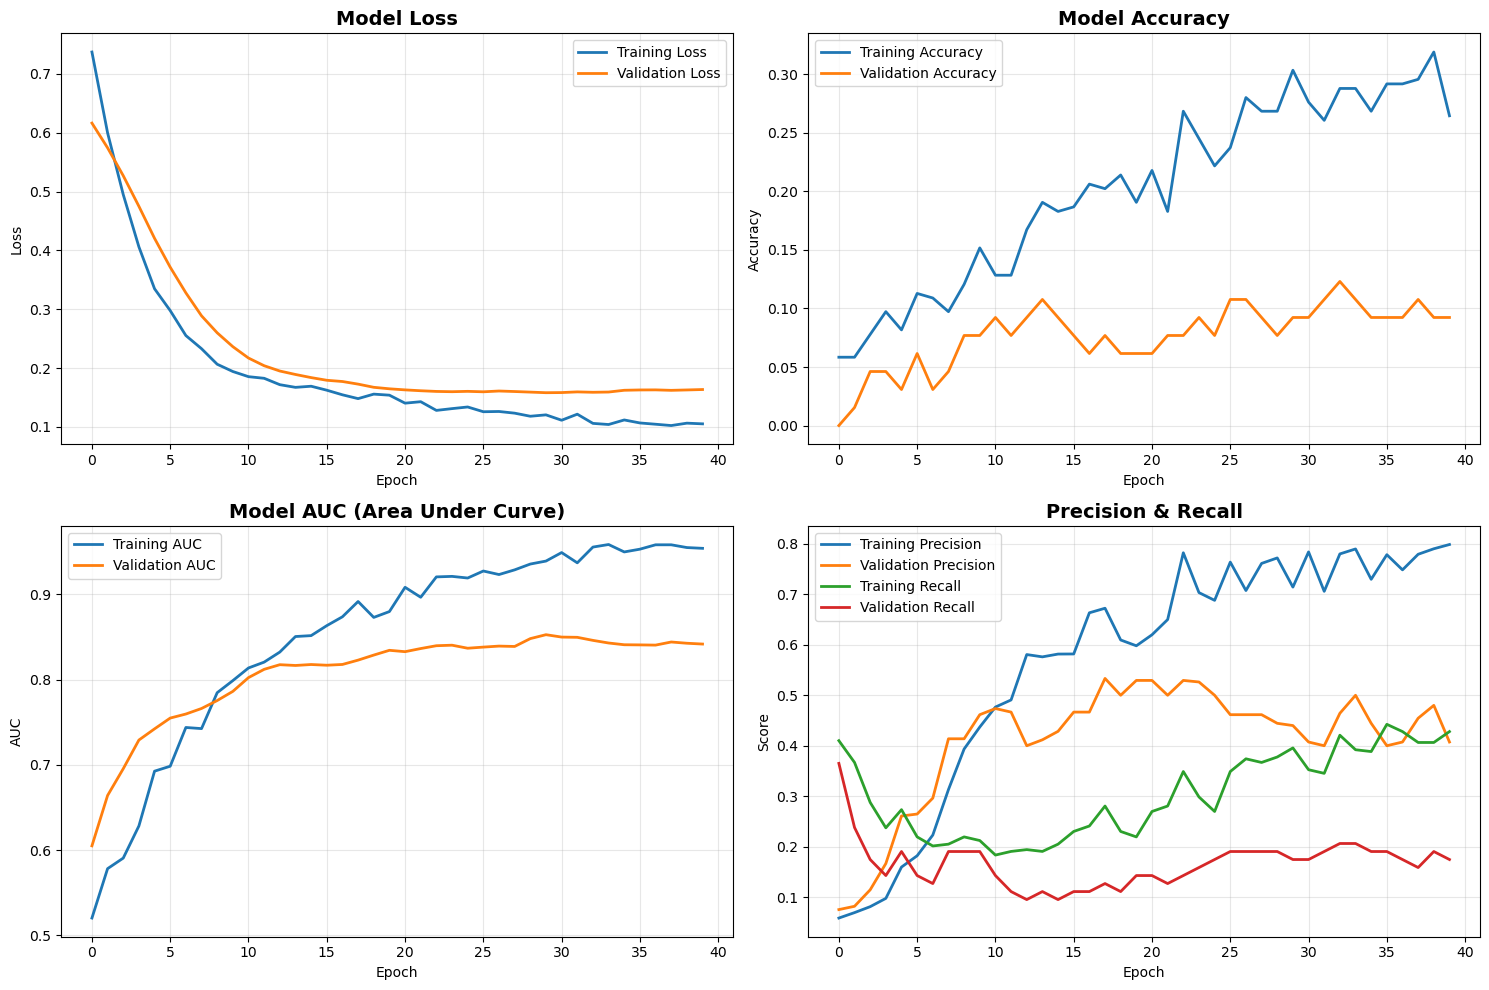


Training afgerond!


In [49]:
print("="*70)
print("TRAINING VISUALISATIE")
print("="*70)

# Plot loss en metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. AUC
axes[1, 0].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[1, 0].set_title('Model AUC (Area Under Curve)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining afgerond!")